# Machine Learning

> "L'aprenentatge automàtic ("machine learning" en anglès) és un camp de la intel·ligència artificial que està dedicat al disseny, l'anàlisi i el desenvolupament d'algorismes i tècniques que permeten que les màquines evolucionin. Es una àrea multidisciplinària que, a través de ciències com la computació, les matemàtiques, la lògica i la filosofia, estudia la creació i el disseny de programes capaços de generalitzar comportaments a partir del reconeixement de patrons o classificació i de sistemes capaços de resoldre problemes quotidians per si mateixos, utilitzant com a paradigma la intel·ligència humana." [Link](https://ca.wikipedia.org/wiki/Aprenentatge_autom%C3%A0tic)


## Tasques més habituals de ML 

Podem classificar les tasques segons l'activitat a resoldre[3]:

- **Classificació** (*Classification and class probability estimation*). Per a cada individu d'una població estimar el conjunt de classes, també conegut com una categoria, al qual pertany. Exemples: quins grups de clients reaccionaran a una oferta? Quins clients accedirien a realitzar una enquesta telefònica? etc.
- **Regressió** (*Regression - value estimation*). S'intenta estimar o predir el valor numèric d'una variable. Exemple: quants clients empraran un servei?. La regressió està relacionada amb la classificació. La classificació prediu **si alguna cosa passarà** i la regressió **quan ocorrerà**.
- **Agrupació** (*Clustering*). És la tasca d'intentar agrupar elements d'una població que comparteixin similituds. Exemple: Quina relació guarden aquests clients?
- **Modelització de causes**( *Casual modeling*). Intenta ajudar a comprendre la influència mútua d'esdeveniments o accions. Exemple: Què t'ha portat a comprar aquest producte?
- 
## Classificació

L'objectiu de la classificació és predir les etiquetes de classe de noves instàncies. Aquestes etiquetes de classe són valors discrets i desordenats que poden entendre's com la filiació de la instància a un grup.

Existeixen dos tipus de classificadors segons el nombre de classes:

- Binaris. Prediuen un resultat binari. Hi ha dos tipus de classes, per exemple: *yes/no, pass/fail, spam/not spam, etc.*
- Multiclasse. Com s'indica existeixen més de dues classes, per exemple: *gèneres narratius, etiquetes mediambientals, etc.*


In [15]:
import numpy as np
from sklearn import linear_model
from sklearn.model_selection import train_test_split

from matplotlib import pyplot as plt

In [16]:
data = np.random.rand(2500, 2)

data = data[((data[:, 0] > 0.6) | (data[:, 0] < 0.4)), :]
data = data[((data[:, 1] > 0.6) | (data[:, 1] < 0.4)), :]

label = (data[:, 0] > 0.5) & (data[:, 1] > 0.5).astype(np.uint8)

# Segona pràctica (ML): perceptró.

Aquesta primera pràctica veurem com es dur a terme un entrenament d'aprenentatge automàtic. Hem de dur a terme el procés que heu vist a teoria:

![proces](proces.png)

# Dataset 

El primer que hem de fer es saber com són les dades. Ja que són **dades 2D**. Per visualizar-ho empram la llibreria *matplotlib*.

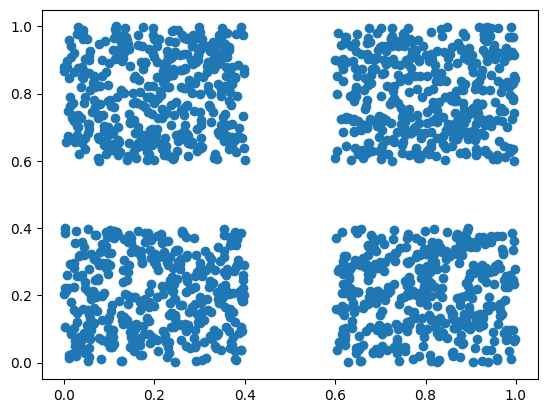

In [17]:
plt.scatter(data[:, 0], data[:, 1]);

Es interessant saber com es localitza l'etiqueta. Per fer-ho mostram cada punt a quina classe correspon.

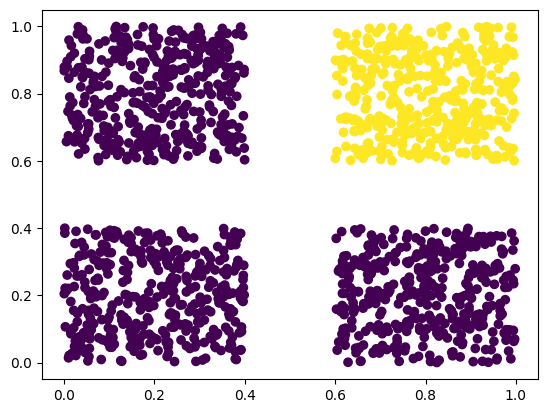

In [18]:
plt.scatter(data[:, 0], data[:, 1], c=label);

Em de dividir les dades entre train i test. Per fer-ho emprarem les eines que tenim amb la lliberia *scikit-learn*. Em de definir:
* La mida del test.
* Un random state. Ens permet que sempre es divideix igual.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    data, label, test_size=0.33, random_state=42
)

# Entrenament 

Entrenam un classificador, en particular un **Perceptró**. Un classificador és un model que ens permet fer prediccions binàries. Per entrenar-ho em de tenir en compte dues coses:
* Cada model té parametres que determinen com actuen.
* **Només em d'entrenar amb les dades d'entrenament**. 

In [20]:
clf = linear_model.Perceptron(tol=1e-9, random_state=42)
clf.fit(X_train, y_train);

El perceptró apren una divisió lineal. Podem mostrar aquesta divisió.

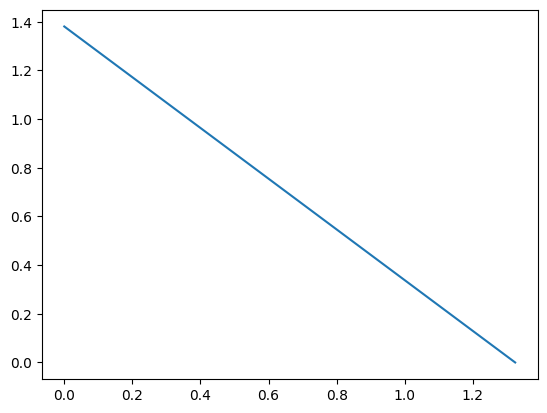

In [21]:
x_intercept = (0, (-clf.intercept_ / clf.coef_[0][1])[0])
y_intercept = ((-clf.intercept_ / clf.coef_[0][0])[0], 0)

plt.plot(x_intercept, y_intercept);

Evidentment la divisió per ella tota sola no ens permet observar res. A la següent passa li donarem sentit. El que podem veure és els seus valors, que es relacionen amb la formulació que heu vist a teoria. En particular podem veure com defineix una divisió tot seguint la formula d'una recta:

$$ h_\theta(x) = \theta_0 \sum^n_{j=1} x_j \cdot \theta_j$$

In [8]:
print(f"Valor de bias: {clf.intercept_} - Valor dels pesos: {clf.coef_}")

Valor de bias: [-13.] - Valor dels pesos: [[9.34234   9.9962835]]


## Predicció i performance

Ho combinam amb la informació que tenim de test per observar si ha fet la divisió correctament. Per fer-ho, primer fem la predicció del conjunt de test.

In [22]:
pred = clf.predict(X_test)

/Users/hexdhog/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hexdhog/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hexdhog/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [23]:
pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,

Després pintam les dades, la seva predicció i la divisió.

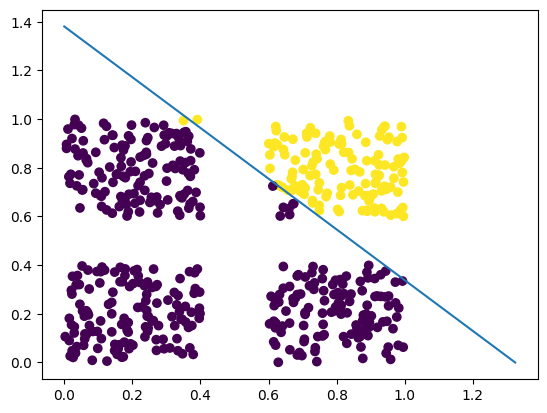

In [24]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=pred)
plt.plot(x_intercept, y_intercept);

Obtenim les mètriques per saber si els resultats són millors o pitjors. Coneixem quatre mesures: *accuracy, recall, precision i F1-Score*. Podem emprar directament una eina que ho resumeix.

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       392
           1       0.98      0.95      0.97       133

    accuracy                           0.98       525
   macro avg       0.98      0.97      0.98       525
weighted avg       0.98      0.98      0.98       525



# Pràctica

## Primeres dades

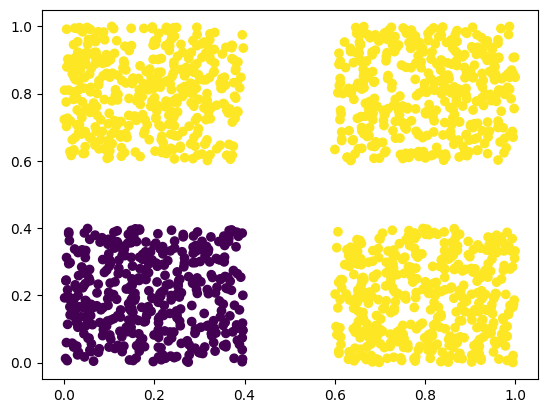

In [26]:
data = np.random.rand(2500, 2)

data = data[((data[:, 0] > 0.6) | (data[:, 0] < 0.4)), :]
data = data[((data[:, 1] > 0.6) | (data[:, 1] < 0.4)), :]

label = (data[:, 0] > 0.5) | (data[:, 1] > 0.5).astype(np.uint8)
plt.scatter(data[:, 0], data[:, 1], c=label);

**Activitat 1**

Donada la següent mostres de dades d'entrenament i un conjunt de dades de prova petit, entrena un model perceptró. Recorda que sempre s'ha de fer la divisió entre conjunt de validació i entrenament. Una vegada entrenat respon a les següent preguntes: 

- On classificaries cadascuna d'elles? Quina accuracy s'ha obtingut?
- Pinta també l'hiperplà que defineix el model.
- Obté les mètriques de validació.

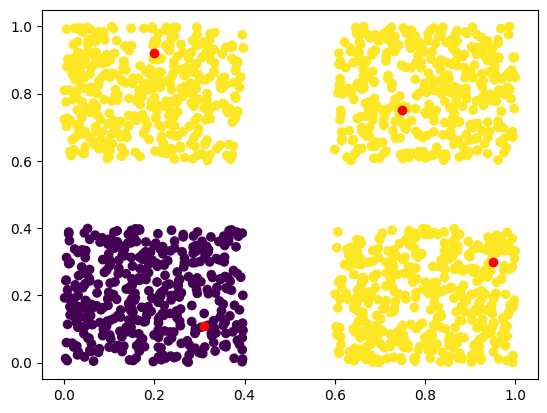

In [28]:
X_test = np.array([[0.75, 0.75],[0.95, 0.3],[0.2, 0.92],[0.31, 0.11]])
plt.scatter(data[:,0], data[:,1], c=label)
plt.scatter(X_test[:,0],X_test[:,1],c="red")

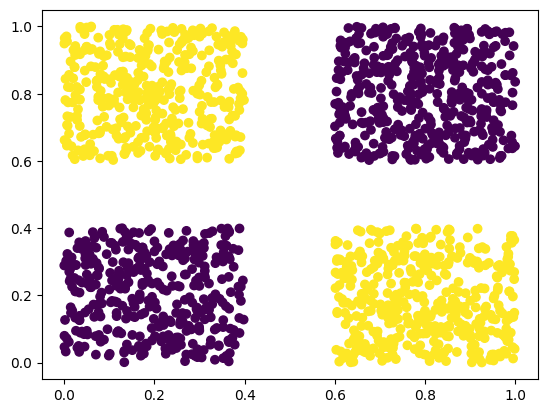

In [26]:
data = np.random.rand(2500, 2)

data = data[((data[:, 0] > 0.6) | (data[:, 0] < 0.4)), :]
data = data[((data[:, 1] > 0.6) | (data[:, 1] < 0.4)), :]

label = np.bitwise_xor((data[:, 0] > 0.5), (data[:, 1] > 0.5)).astype(np.uint8)
plt.scatter(data[:, 0], data[:, 1], c=label);

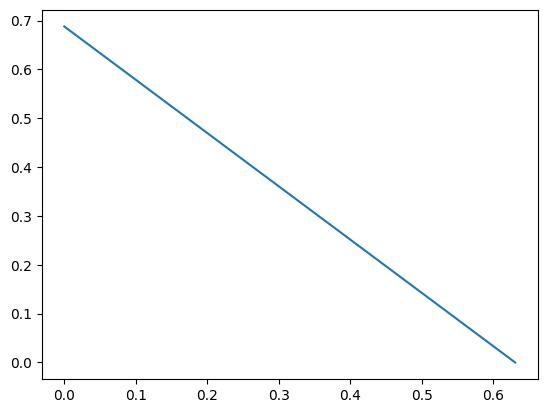

In [42]:
X_train, X_test, y_train, y_test = train_test_split(data, label, test_size=0.33, random_state=42)

clf = linear_model.Perceptron(tol=1e-9, random_state=42)
clf.fit(X_train, y_train)

x_intercept = (0, (-clf.intercept_ / clf.coef_[0][1])[0])
y_intercept = ((-clf.intercept_ / clf.coef_[0][0])[0], 0)
plt.plot(x_intercept, y_intercept)

In [43]:

pred = clf.predict(X_test)
print(pred)

[1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1
 1 0 0 1 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1
 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 0 0 1 1 1 0 1 0 0 1 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 0 1 0 1 0 0 1 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 0 1 1 1 1 1 1 1 0 1 1 0 1 0 1 0 0 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1
 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 0 0 1 1 1 1 0 0 1 1 1 0 0 0
 0 1 0 1 0 0 1 0 0 1 1 1 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1
 1 0 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0
 1 0 1 1 1 1 0 1 1 0 1 0 1 1 1 1 0 0 1 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 0 1 1
 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 1 0 1 0 1 0 1 1 1 1 0 0 1 1 1 0 1 1 1
 1 1 0 0 1 0 1 0 1 1 1 1 0 0 0 1 0 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 0 1
 0 1 1 0 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 1 1 

/Users/hexdhog/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hexdhog/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hexdhog/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


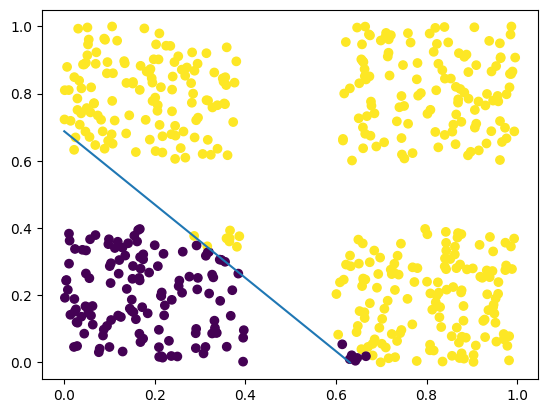

In [45]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=pred)
plt.plot(x_intercept, y_intercept)

In [47]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       136
           1       0.98      0.98      0.98       392

    accuracy                           0.97       528
   macro avg       0.97      0.96      0.97       528
weighted avg       0.97      0.97      0.97       528

